
## Submitted By

**Name:** Neha Chouhan  
**Course:** B.Tech (Artificial Intelligence)  
**Section:** B  
**Enrollment No.:** 24ADV3ARI0023

---


# Import Required Libraries



In [350]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")
sns.set_palette("viridis")

In [351]:
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Prediction%20dataset.csv"

df = pd.read_csv(url)

# EDA

In [352]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0


In [353]:
df.shape

(49999, 10)

In [354]:
print(df["Crop"].unique())

['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut '
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower' 'Bajra' 'Castor seed'
 'Cotton(lint)' 'Horse-gram' 'Jowar' 'Korra' 'Ragi' 'Tobacco' 'Gram'
 'Wheat' 'Masoor' 'Sesamum' 'Linseed' 'Safflower' 'Onion'
 'other misc. pulses' 'Samai' 'Small millets' 'Coriander' 'Potato'
 'Other  Rabi pulses' 'Soyabean' 'Beans & Mutter(Vegetable)' 'Bhindi'
 'Brinjal' 'Citrus Fruit' 'Cucumber' 'Grapes' 'Mango' 'Orange'
 'other fibres' 'Other Fresh Fruits' 'Other Vegetables' 'Papaya'
 'Pome Fruit' 'Tomato' 'Rapeseed &Mustard' 'Mesta' 'Cowpea(Lobia)' 'Lemon'
 'Pome Granet' 'Sapota' 'Cabbage' 'Peas  (vegetable)' 'Niger seed'
 'Bottle Gourd' 'Sannhamp' 'Varagu' 'Garlic' 'Ginger' 'Oilseeds total'
 'Pulses total' 'Jute' 'Peas & beans (Pulses)' 'Blackgram' 'Paddy'
 'Pineapple' 'Barley' 'Khesari' 'Guar seed']


In [355]:
print(df["State_Name"].unique())

['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh']


In [356]:
print(df["Season"].unique())

['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']


removing extra space

In [357]:
df["Season"] = df["Season"].str.strip()
df["State_Name"] = df["State_Name"].str.strip()
df["District_Name"] = df["District_Name"].str.strip()
df["Crop"] = df["Crop"].str.strip()

In [358]:
print(df["Season"].unique())
print(df["State_Name"].unique())
print(df["District_Name"].unique()[:5])
print(df["Crop"].unique()[:5])


['Kharif' 'Whole Year' 'Autumn' 'Rabi' 'Summer' 'Winter']
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh']
['NICOBARS' 'NORTH AND MIDDLE ANDAMAN' 'SOUTH ANDAMANS' 'ANANTAPUR'
 'CHITTOOR']
['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut']


In [359]:
df[df["State_Name"] == "Andhra Pradesh"]["District_Name"].unique()

array(['ANANTAPUR', 'CHITTOOR', 'EAST GODAVARI', 'GUNTUR', 'KADAPA',
       'KRISHNA', 'KURNOOL', 'PRAKASAM', 'SPSR NELLORE', 'SRIKAKULAM',
       'VISAKHAPATANAM', 'VIZIANAGARAM', 'WEST GODAVARI'], dtype=object)

In [360]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop',
       'Temperature', 'Humidity', 'Soil_Moisture', 'Area', 'Production'],
      dtype='object')

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     49999 non-null  object 
 1   District_Name  49999 non-null  object 
 2   Crop_Year      49999 non-null  int64  
 3   Season         49999 non-null  object 
 4   Crop           49999 non-null  object 
 5   Temperature    49999 non-null  int64  
 6   Humidity       49999 non-null  int64  
 7   Soil_Moisture  49999 non-null  int64  
 8   Area           49999 non-null  float64
 9   Production     49784 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 3.8+ MB


In [362]:
df.describe()

,Crop_Year,Temperature,Humidity,Soil_Moisture,Area,Production
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.978400e+04
mean,2005.879138,34.445489,44.776116,53.110502,7363.389469,4.132019e+05
std,5.106092,3.498524,6.662406,5.258764,27927.935789,1.232609e+07
min,1997.000000,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,2002.000000,34.000000,40.000000,50.000000,76.000000,8.700000e+01
50%,2006.000000,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,2010.000000,36.000000,50.000000,55.000000,2546.500000,5.615000e+03
max,2014.000000,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


Data Cleaning

In [363]:
df.isnull().sum()

State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Temperature        0
Humidity           0
Soil_Moisture      0
Area               0
Production       215
dtype: int64

In [364]:
df = df.dropna(subset=["Production"])

Since only 215 out of 49,999 rows have missing values (less than 0.5%), removing them has very little impact on the dataset. Filling the target with estimated values could introduce incorrect information and reduce model quality.

In [365]:
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Temperature      0
Humidity         0
Soil_Moisture    0
Area             0
Production       0
dtype: int64

In [366]:
df.shape

(49784, 10)

In [367]:
# Check for Zero Area and Production

df = df[(df["Area"] > 0) & (df["Production"] > 0)]

In [368]:
print((df["Production"] == 0).sum())
print((df["Area"] == 0).sum())

0
0


we are going to calculate Yield using Production ÷ Area. If Area is zero, it causes a division by zero error.

Create Yield Column

In [369]:
df["Yield"] = df["Production"] / df["Area"]

In [370]:
df["Yield"].describe()

count    49675.000000
mean        84.418067
std        930.718123
min          0.000505
25%          0.619400
50%          1.055944
75%          2.892503
max      33089.005477
Name: Yield, dtype: float64

In [371]:
cutoff = df["Yield"].quantile(0.95)

df = df[df["Yield"] <= cutoff]

remove outliers before creating Yield, it doesn't make sense because the Yield column doesn't exist yet.

In [372]:
df["Yield"].describe()

count    47192.000000
mean         2.410858
std          3.377409
min          0.000505
25%          0.600000
50%          1.000000
75%          2.275156
max         18.750000
Name: Yield, dtype: float64

In [373]:
df[["Production", "Area", "Yield"]].head()

,Production,Area,Yield
0,2000.0,1254.0,1.594896
1,1.0,2.0,0.500000
2,321.0,102.0,3.147059
3,641.0,176.0,3.642045
4,165.0,720.0,0.229167


Production depends on the size of the land. A farmer with more land usually produces more crops. Yield measures production per unit area, making it a fair and meaningful value to predict.

In [374]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0,0.229167


# Encoding

In [375]:
state_encoder = LabelEncoder()
district_encoder = LabelEncoder()
season_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

df["State_Name_encoded"] = state_encoder.fit_transform(df["State_Name"])
df["District_Name_encoded"] = district_encoder.fit_transform(df["District_Name"])
df["Season_encoded"] = season_encoder.fit_transform(df["Season"])
df["Crop_encoded"] = crop_encoder.fit_transform(df["Crop"])




In [376]:
# Store encoders in a dictionary
encoders = {
    "State_Name": state_encoder,
    "District_Name": district_encoder,
    "Season": season_encoder,
    "Crop": crop_encoder
}

In [377]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production,Yield,State_Name_encoded,District_Name_encoded,Season_encoded,Crop_encoded
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0,1.594896,0,78,1,0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0,0.500000,0,78,1,44
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0,3.147059,0,78,1,55
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0,3.642045,0,78,4,3
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0,0.229167,0,78,4,11


In [378]:
# features and target variabl
X = df[
    [
        "State_Name_encoded",
        "District_Name_encoded",
        "Season_encoded",
        "Crop_encoded",
        "Crop_Year",
        "Temperature",
        "Humidity",
        "Soil_Moisture"
    ]
]

y = df["Yield"]

remove Production from X Because Yield is calculated using Production. Including Production as a feature would leak information about the target into the model, resulting in misleadingly high accuracy.

In [379]:
print(X.head())
print(y.head())

   State_Name_encoded  District_Name_encoded  Season_encoded  Crop_encoded  \
0                   0                     78               1             0   
1                   0                     78               1            44   
2                   0                     78               1            55   
3                   0                     78               4             3   
4                   0                     78               4            11   

   Crop_Year  Temperature  Humidity  Soil_Moisture  
0       2000           36        35             45  
1       2000           37        40             46  
2       2000           36        41             50  
3       2000           37        42             55  
4       2000           36        40             54  
0    1.594896
1    0.500000
2    3.147059
3    3.642045
4    0.229167
Name: Yield, dtype: float64


# Train-Test Split

In [380]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [381]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (37753, 8)
X_test  : (9439, 8)
y_train : (37753,)
y_test  : (9439,)


# Linear Regression

In [382]:
lr_model = LinearRegression()

In [383]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [384]:
y_pred_lr = lr_model.predict(X_test)

Evaluate the Model

In [385]:
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression R² Score:", r2_lr)

Linear Regression R² Score: 0.08011223370005593


In [386]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 2.1082557347985103


In [387]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 3.2257849790618605


# Random Forest Regressor

In [388]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42
)


In [389]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, random_state=42)

In [390]:
y_pred_rf = rf_model.predict(X_test)

In [391]:
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest R² Score: 0.9180832690744757


In [392]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("Random Forest MAE:", mae_rf)

Random Forest MAE: 0.46743962844287307


In [393]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 0.9626187129130415


# Compare Both Models

In [394]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,2.108256,3.225785,0.080112
1,Random Forest Regressor,0.467440,0.962619,0.918083


So we choose Random Forest Regressor Because it achieved the best performance with a lower MAE, lower RMSE, and higher R² Score compared to Linear Regression.

In [395]:
# Feature Importance from Random forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,Crop_encoded,0.680474
2,Season_encoded,0.122459
0,State_Name_encoded,0.117376
4,Crop_Year,0.044366
1,District_Name_encoded,0.024232
7,Soil_Moisture,0.004416
5,Temperature,0.003535
6,Humidity,0.003142


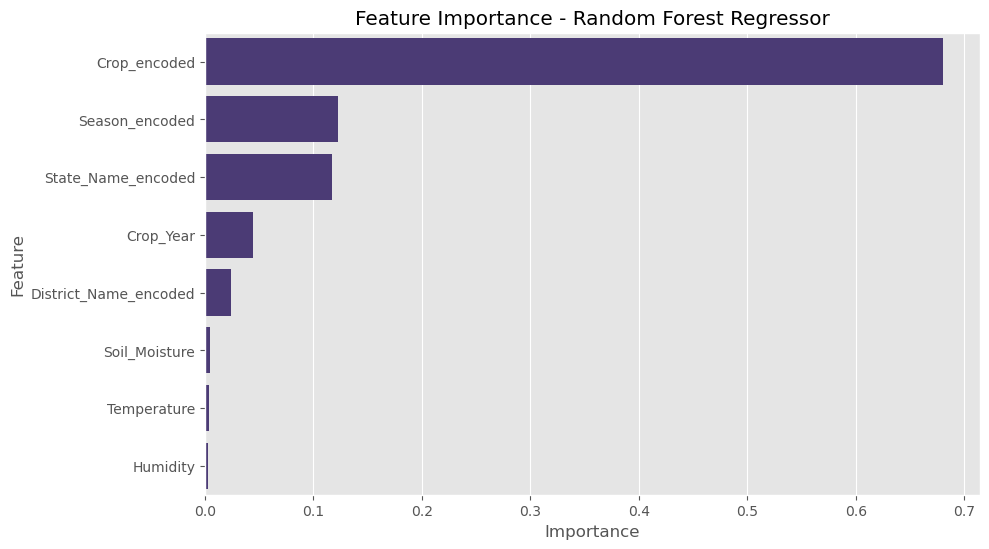

In [396]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest Regressor")
plt.show()

Create predict_yield() Function

In [397]:
def predict_yield(
    state,
    district,
    year,
    season,
    crop,
    temperature,
    humidity,
    soil_moisture
):

    try:
        state = state_encoder.transform([state])[0]
        district = district_encoder.transform([district])[0]
        season = season_encoder.transform([season])[0]
        crop = crop_encoder.transform([crop])[0]

    except ValueError:
        return None

    input_data = pd.DataFrame({
        "State_Name_encoded": [state],
        "District_Name_encoded": [district],
        "Season_encoded": [season],
        "Crop_encoded": [crop],
        "Crop_Year": [year],
        "Temperature": [temperature],
        "Humidity": [humidity],
        "Soil_Moisture": [soil_moisture]
    })

    prediction = rf_model.predict(input_data)

    return round(float(prediction[0]), 2)

In [398]:
# Test

predict_yield(
    state="Andhra Pradesh",
    district="ANANTAPUR",
    year=2023,
    season="Kharif",
    crop="Rice",
    temperature=25,
    humidity=80,
    soil_moisture=45
)

print(predict_yield)

<function predict_yield at 0x0000017DA9D84680>


In [399]:
# save the model

joblib.dump(rf_model, "yield_prediction_model.pkl")

['yield_prediction_model.pkl']

In [400]:


joblib.dump(state_encoder, "state_encoder.pkl")
joblib.dump(district_encoder, "district_encoder.pkl")
joblib.dump(season_encoder, "season_encoder.pkl")
joblib.dump(crop_encoder, "crop_encoder.pkl")

['crop_encoder.pkl']

# conclusion

Successfully loaded and explored the crop production dataset containing historical agricultural records.
Performed detailed data cleaning by removing extra spaces, handling missing values, removing zero-area and zero-production records, creating the Yield column, and removing extreme outliers using the 95th percentile.

Encoded categorical features using four separate LabelEncoder objects for State, District, Season, and Crop.
Selected four categorical and four numerical features for regression model training.
Trained and compared Linear Regression and Random Forest Regressor models.

Evaluated both models using MAE, RMSE, and R² Score.
Selected Random Forest Regressor as the final model because it provided significantly better prediction accuracy.

Analyzed feature importance to understand which variables contributed most to yield prediction.
Saved the trained model and all encoders using Joblib for future use.

Developed a reusable predict_yield() function with error handling to safely predict crop yield for valid user inputs.
Standardized crop and season names to avoid integration issues caused by inconsistent dataset formats.
The module successfully estimates crop yield and serves as the second stage of the Smart Crop Advisory System.